# **WENDy for ODEs: Examples**

- Based on the [BMB paper by **D. M. Bortz**, **D. A. Messenger**, **V. Dukic** (2023)](https://doi.org/10.1007/s11538-023-01208-6).
<!-- - See the authors' original [MatLab code repository](https://github.com/MathBioCU/WSINDy_PDE). -->

April Tran, Dan Messenger, 2026

---

This notebook illustrates the WENDy algorithm being applied to various ODE systems
<!-- - the $(1+1)$-dimensional Kuramoto Sivashinsky equation
- the $(2+1)$-dimensional Swift Hohenberg equation
- the $(3+1)$-dimensional MHD equations -->

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.integrate import solve_ivp
import time

import os
import sys
import json
from pathlib import Path
try:
    kernel_info_path = Path(sys.argv[-1])
    notebook_path = json.loads(kernel_info_path.read_bytes())['jupyter_session']
    notebook_dir = os.path.dirname(notebook_path)
except (IndexError, KeyError, json.JSONDecodeError, FileNotFoundError):
    # Fallback to current working directory if parsing fails
    notebook_dir = os.getcwd() 
parent_dir = os.path.dirname(notebook_dir)
sys.path.append(parent_dir+'/libs/pywsindy_base')

from WENDy import *
from ode_systems import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Logistic Growth

/home/danielmessenger/anaconda3/envs/pywsindy/lib/python3.14/site-packages/scipy/integrate/_ivp/ivp.py:626: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)
/home/danielmessenger/repos/WSciML-SIAMWorkshop2026/libs/pywsindy_base/WENDy.py:616: RuntimeWarning: invalid value encountered in scalar divide
  m = (U[-1] - U[0]) / (x[-1] - x[0])


num timepoints=251
Radius: 19
Param error: 6.360%
FS error: 4.091%
Runtime 0.176s


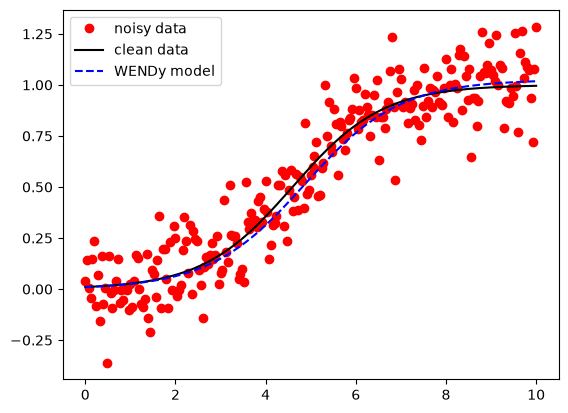

In [2]:
x, t, params, x0, true_vec, features,rhs_p = logistic_growth()

subsamp =  2 # subsample data in time
tobs = t[::subsamp]
xobs = x[::subsamp, :]
M, nstates = xobs.shape

#add noise
#np.random.seed(1)
noise_ratio = 0.2
noise_dist = 0
noise_alg = 0
#rng_seed = np.random.get_state()[1][2]
#np.random.seed(rng_seed)
xobs_n, noise, _, sigma = gen_noise(xobs, noise_ratio, noise_dist, noise_alg)

#IRLS - SL
start = time.time()
IRSL_SL_model = WENDy(features)
w_hat = IRSL_SL_model.fit_IRLS(xobs_n, tobs, radius = None, gap = 1, type_rad=0, p = 16, S = 1, mu = [1, 2, 1], toggle_SVD=False, diag_reg=1e-10, trunc=0)
runtime = time.time() - start
u_hat = IRSL_SL_model.simulate(x0=xobs[0], t=tobs)

E_2 = np.linalg.norm(w_hat - true_vec)/np.linalg.norm(true_vec)*100
E_FS = np.linalg.norm(u_hat - xobs, 'fro')/np.linalg.norm(xobs, 'fro')*100

print(f"num timepoints={M}")
print('Radius:', *IRSL_SL_model.radius)
print('Param error:',  f"{E_2:.3f}%")
print("FS error:", f"{E_FS:.3f}%")
print('Runtime', f"{runtime:.3f}s")

plt.plot(tobs, xobs_n, 'ro', label='noisy data')
plt.plot(tobs, xobs, 'k-', label='clean data')
plt.plot(tobs, u_hat, 'b--', label='WENDy model')
plt.legend()

# Lorenz 63

num timepoints=501


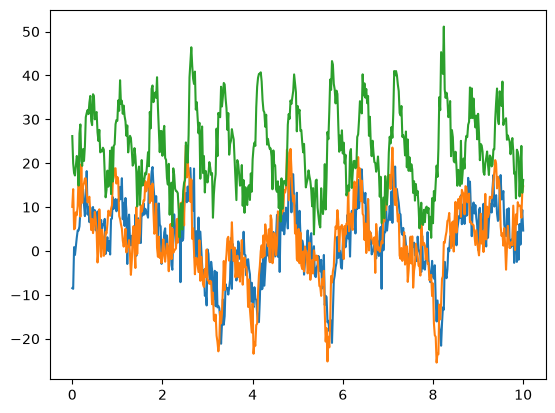

In [3]:
x, t, params, x0, true_vec, features,rhs_p = lorenz()

subsamp =  1 # subsample data in time
tobs = t[::subsamp]
xobs = x[::subsamp, :]
M, nstates = xobs.shape

#add noise
#np.random.seed(1)
noise_ratio = 0.2
noise_dist = 0
noise_alg = 0
#rng_seed = np.random.get_state()[1][2]
#np.random.seed(rng_seed)
xobs_n, noise, _, sigma = gen_noise(xobs, noise_ratio, noise_dist, noise_alg)
print(f"num timepoints={M}")
plt.plot(tobs, xobs_n);

Radius: 22
Param error: 6.431%
FS error: 67.283%
Runtime 5.075s


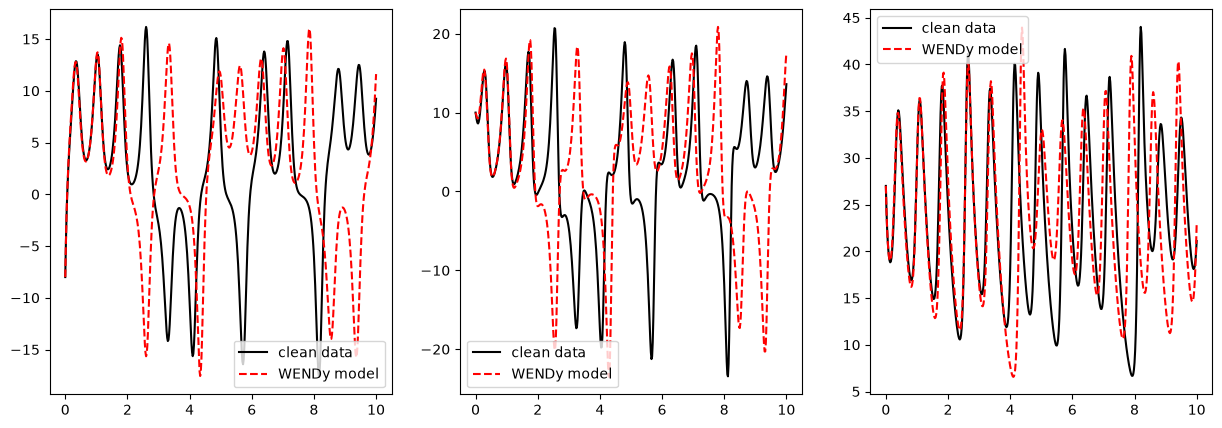

In [4]:
#IRLS - SL
start = time.time()
IRSL_SL_model = WENDy(features)
w_hat = IRSL_SL_model.fit_IRLS(xobs_n, tobs, radius = None, gap = 1, type_rad=0, p = 16, S = 1, mu = [1, 2, 1], toggle_SVD=False, diag_reg=1e-10, trunc=0)
runtime = time.time() - start
u_hat = IRSL_SL_model.simulate(x0=xobs[0], t=tobs)

E_2 = np.linalg.norm(w_hat - true_vec)/np.linalg.norm(true_vec)*100
E_FS = np.linalg.norm(u_hat - xobs, 'fro')/np.linalg.norm(xobs, 'fro')*100

print('Radius:', *IRSL_SL_model.radius)
print('Param error:',  f"{E_2:.3f}%")
print("FS error:", f"{E_FS:.3f}%")
print('Runtime', f"{runtime:.3f}s")

fig,ax = plt.subplots(1,nstates,figsize=(15,5))
for a, x, u in zip(ax,xobs.T,u_hat.T):
    a.plot(tobs, x, 'k-', label='clean data')
    a.plot(tobs, u, 'r--', label='WENDy model')
    a.legend()

# Hindmarsh-Rose

num timepoints=512


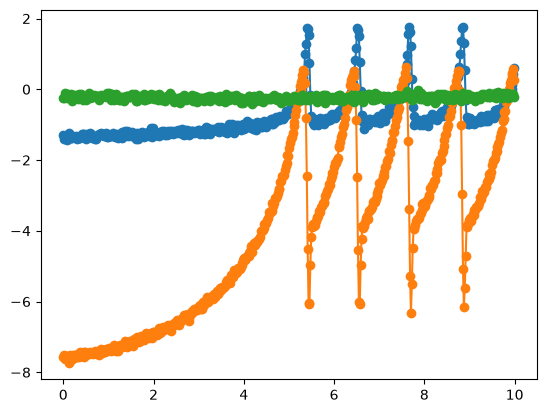

In [39]:
x, t, params, x0, true_vec, features,rhs_p = HindmarshRose()

subsamp =  2 # subsample data in time
tobs = t[::subsamp]
xobs = x[::subsamp, :]
M, nstates = xobs.shape

#add noise
#np.random.seed(1)
noise_ratio = 0.02
noise_dist = 0
noise_alg = 0
#rng_seed = np.random.get_state()[1][2]
#np.random.seed(rng_seed)
xobs_n, noise, _, sigma = gen_noise(xobs, noise_ratio, noise_dist, noise_alg)
print(f"num timepoints={M}")
plt.plot(tobs, xobs_n,'-o');

Radius: 20
Param error: 2.903%
FS error: 18.776%
Runtime 4.308s


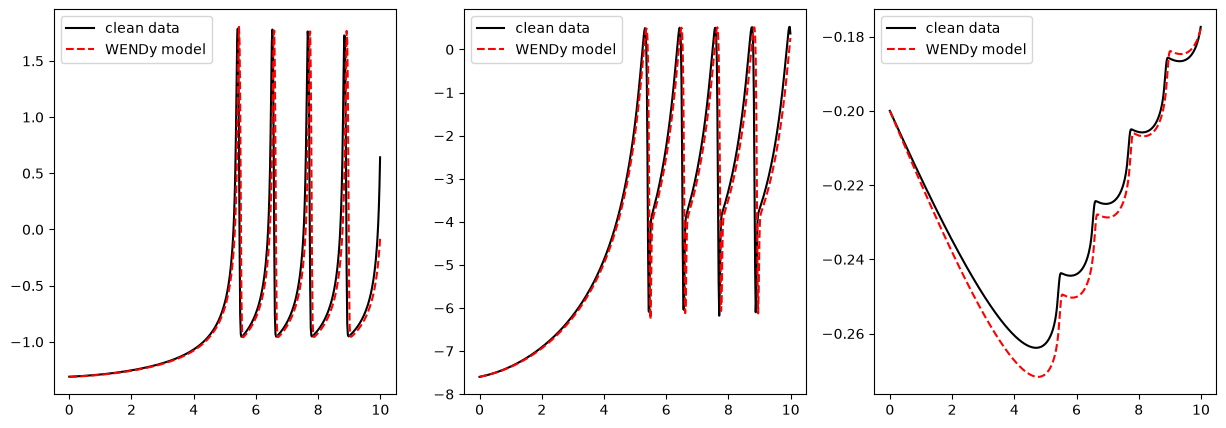

In [40]:
#IRLS - SL
start = time.time()
IRSL_SL_model = WENDy(features)
w_hat = IRSL_SL_model.fit_IRLS(xobs_n, tobs, 
       radius = None, gap = 1, type_rad=0, 
       p = 15, S = 1, mu = [1, 2, 1], 
       toggle_SVD=False, diag_reg=1e-10, trunc=0)
runtime = time.time() - start
u_hat = IRSL_SL_model.simulate(x0=xobs[0], t=tobs)

E_2 = np.linalg.norm(w_hat - true_vec)/np.linalg.norm(true_vec)*100
E_FS = np.linalg.norm(u_hat - xobs, 'fro')/np.linalg.norm(xobs, 'fro')*100

print('Radius:', *IRSL_SL_model.radius)
print('Param error:',  f"{E_2:.3f}%")
print("FS error:", f"{E_FS:.3f}%")
print('Runtime', f"{runtime:.3f}s")

fig,ax = plt.subplots(1,nstates,figsize=(15,5))
for a, x, u in zip(ax,xobs.T,u_hat.T):
    a.plot(tobs, x, 'k-', label='clean data')
    a.plot(tobs, u, 'r--', label='WENDy model')
    a.legend()